# Сверточные сети

Разнообразие слоев для сверточной сети опирается на понятие тензор и его обработку в средах типа TensorFlow.

Тензор - объект линейной алгебры, линейно преобразующий элементы одного линейного пространства в элементы другого

Ранг тензора — это количество его индексов

Сверточные нейронные сети - это нейронные сети приспособленные впервую очередь для задач распознования образов. В их основе лежат работы в области изучения зрительной коры головного мозга. Их отличительная черта - добавление сверточных и пуллинговых слоев в архитектуру нейронной сети


## 1.1 Сверточный слой

Посмотрим как работает наложение фильтра на изображение

Прочитаем изображение и следаем его свертку с некоторым фильтром (воспользуемся средствами OpenCV (cv2) и scipy)




In [ ]:
import cv2
import numpy as np
from scipy import datasets

i_mage = datasets.ascent()

Исходное изображение

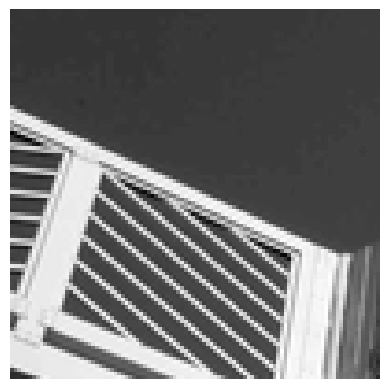

In [ ]:
import matplotlib.pyplot as plt

plt.grid(False)
plt.gray()
plt.axis("off")
plt.imshow(i_mage[50:150, :100])
plt.show()

Создадим фильтр

In [ ]:
i_mage = i_mage.astype(np.float32)
i_transformed = np.copy(i_mage)
size_x = i_transformed.shape[0]
size_y = i_transformed.shape[1]

# Фильтры края.

# Разные фильтры.
filter = [[0, 1, 0], [1, -4, 1], [0, 1, 0]]

# Много разных
# filter = [ [-1, -2, -1], [0, 0, 0], [1, 2, 1]]
# filter = [ [-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]

# зададим вес для свертки
weight = 1

Наложим фильтр на изображение, используем скользящее окно и поэлементное вычисление свертки

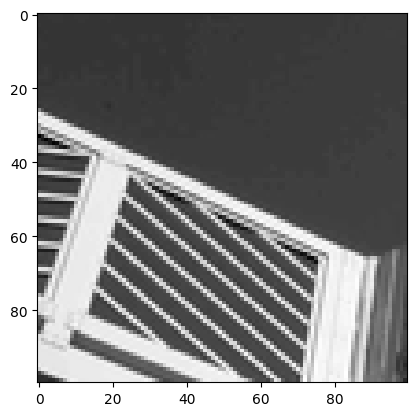

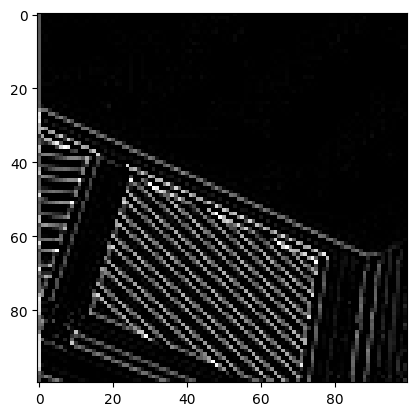

In [ ]:
for x in range(1, size_x - 1):
    for y in range(1, size_y - 1):
        # convolution
        convolution = 0.0
        convolution = convolution + (i_mage[x - 1, y - 1] * filter[0][0])
        convolution = convolution + (i_mage[x, y - 1] * filter[0][1])
        convolution = convolution + (i_mage[x + 1, y - 1] * filter[0][2])
        convolution = convolution + (i_mage[x - 1, y] * filter[1][0])
        convolution = convolution + (i_mage[x, y] * filter[1][1])
        convolution = convolution + (i_mage[x + 1, y] * filter[1][2])
        convolution = convolution + (i_mage[x - 1, y + 1] * filter[2][0])
        convolution = convolution + (i_mage[x, y + 1] * filter[2][1])
        convolution = convolution + (i_mage[x + 1, y + 1] * filter[2][2])
        convolution = convolution * weight
        if convolution < 0:
            convolution = 0
        if convolution > 255:
            convolution = 255
        i_transformed[x, y] = convolution

# Plot исходное изображение
plt.gray()
plt.grid(False)
plt.imshow(i_mage[50:150, :100])
# plt.axis('off')
plt.show()
# Plot фильтрованное изображение
plt.gray()
plt.grid(False)
plt.imshow(np.abs(i_transformed[50:150, :100]))
# plt.axis('off')
plt.show()

Построим модель слоя при прямом распространении сигнала через сверточный слой

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# прямое распространение
def ConvLayer_Forward(Tensor=None, W=None, b=None):
    # на вход:
    # Tensor  - входное изображение
    # W - значения весов нейронов (ядра-фильтры)
    # b - значение сдвигов нейронов
    # на выходе: Output - результат свертки (число каналов = числу фильтров(ядер))

    Output = []
    # print(Tensor.shape)

    iw = 0
    # проходимся по каждому из фильтров
    for f in W:
        print(f)
        output = np.zeros(Tensor.shape[:-1])
        # print(output.shape, f.shape)
        # проходимся по фильтрам
        for y in range(Tensor.shape[0] - f.shape[0]):
            for x in range(Tensor.shape[1] - f.shape[1]):
                sum = 0
                sum = b[iw]  # сразу прибавляем смещение
                sum = sum + np.sum(
                    np.dot(f, Tensor[y : y + f.shape[0], x : x + f.shape[1]])
                )

                output[y, x] = (
                    sum.copy()
                )  # записываем результат свёртки в выходной тензор
        # print(x,y)
        Output.append(output.copy())
        iw += 1
    Output = np.array(Output)
    return Output

Построим модель слоя при обратном распространении сигнала через слой

In [ ]:
def Convolution_Backprop(delta_conv_prev=None, conv_input=None, K=None):
    # входы:
    # delta_conv_prev - ошибка со следующего слоя
    # conv_input - входное изображение на слое
    # K - текущее значение фильтров(ядер - нейроных весов) слоя
    # на выходе
    # dK - поправки для фильтров (без скорости обучения)
    # db - поправки для сдвигов нейрона без скорости обучения
    # I_back - ошибку на входе в сверточный слой
    # Backpropagation

    (n_f, n_c, _) = K.shape
    (_, orig_dim, _) = conv_input.shape
    # строим размер
    dout = np.zeros(conv_input.shape)
    dK = np.zeros(K.shape)
    dbias = np.zeros((n_f, 1))
    iw = 0
    for f in K:
        # по каналам
        out_y = 0
        for y in range(conv_input.shape[0] - f.shape[0]):
            out_x = 0
            for x in range(conv_input.shape[1] - f.shape[1]):
                # градиент loss по всем текущим точкам
                dK[iw, :, :] += (
                    delta_conv_prev[iw, y, x]
                    * conv_input[y : y + f.shape[0], x : x + f.shape[1], 0]
                )
                # print(np.sum(np.abs(delta_conv_prev[iw, y, x] * conv_input[ y:y+f.shape[0], x:x+f.shape[1],:])))
                # перенос loss через этот слой
                dout[y, x, :] += np.sum(delta_conv_prev[iw, y, x] * f)

        # loss gradient of the bias
        dbias[iw] = np.sum(delta_conv_prev[iw])
        iw += 1

    return dout, dK, dbias


Создадим 10 фильтров(ядер-нейронов) сверточного слоя как случайные равномерные с размером 3х3 , создадим изображение (белый прямоугольник на черном фоне) и примени к этому изображению сверточный слой

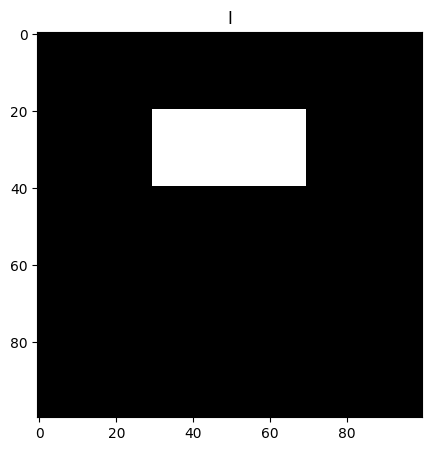

In [ ]:
K = np.random.random((10, 3, 3)) * 10 - 5
b = np.random.random(10) * 0.1

K[0, :, 0] = -1
K[0, :, 2] = 1
K[0, :, 1] = 0
K[0, 1, :] = K[0, 1, :] * 2

I = np.zeros((100, 100, 1))

I[20:40, 30:70, 0] = 1

plt.figure(figsize=(8, 5))
plt.title("I")
plt.imshow(I);

Делаем прямой проход и вычисляем 10 изображений результатов

[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]
[[ 4.33339804 -2.38887309 -2.80641552]
 [ 3.41543026  1.45311281  3.83626269]
 [ 0.44446502  4.66906995  0.37645922]]
[[-2.98578608  3.71078912  4.94834967]
 [ 0.87231605  0.54306398  2.86408104]
 [-3.33965541 -2.47011128 -0.45335956]]
[[-4.94292517  4.74493386  0.80257689]
 [-1.86402655 -1.77735814 -2.37854103]
 [-4.71199028  2.28726528  1.73772404]]
[[ 4.3941747  -4.53438416 -4.79945023]
 [-4.48491598  4.45347752 -1.89941453]
 [ 0.43653388 -1.13852787  1.45230442]]
[[ 3.58990904 -4.33281995 -3.86506336]
 [ 4.37205213  0.52905432  1.03683319]
 [-0.04722217 -1.43854313  4.45271691]]
[[-0.16063677 -3.28650854  1.24582802]
 [ 1.14763082 -2.32889308 -3.14332051]
 [ 3.19838722  3.40824408  2.01440878]]
[[ 2.21812593 -0.21569019 -0.51185335]
 [ 1.59453569 -0.98903134 -2.218786  ]
 [-0.48804465 -1.66624516 -4.11307568]]
[[-1.3852134  -1.51705679  1.65878058]
 [-0.62161269 -3.34482535  0.86592629]
 [ 1.55151219 -4.63470545 -0.93964672]]
[[ 3.29252

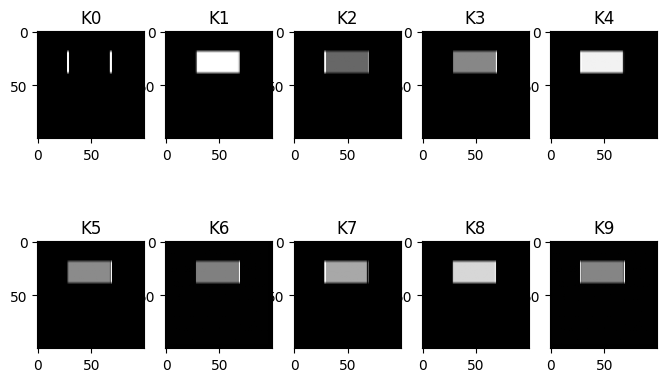

In [ ]:
I_ = ConvLayer_Forward(Tensor=I, W=K, b=b)

plt.figure(figsize=(8, 5)) # Changed figsize to make the plot smaller
for i in [0, 1, 2, 3, 4]:
    for j in [0, 1]:
        plt.subplot(2, 5, i + j * 5 + 1)
        plt.title("K" + str(i + j * 5))
        plt.imshow(np.abs((I_[i + j * 5, :, :]) / np.max(np.abs(I_[i + j * 5, :, :]))))

plt.show()

Делаем обратный проход:
 создаем истиный результат (It) и находим дельту Loss_e (ошибку слоя на выходе (она должна прийти из следующего за текущим слоя ))

 Вернем:

 - dK - поправки для фильтров (без скорости обучения)
 - db - поправки для сдвигов нейрона без скорости обучения
 - I_back - ошибку на входе в сверточный слой

In [ ]:
It = I_ + np.random.random((10, 100, 100)) * 1 - 0.5

Loss_e = It - I_

I_back, dK, db = Convolution_Backprop(delta_conv_prev=Loss_e, conv_input=I, K=K)

In [ ]:
dK

array([[[-12.26104172, -12.07923669, -12.58897631],
        [-11.35854902, -10.62244186, -10.57000249],
        [ -7.44550081,  -6.435663  ,  -6.35746006]],

       [[ 11.78899917,  10.83283506,  10.60564427],
        [  9.8834661 ,   8.33399022,   8.06590391],
        [  8.73080799,   7.20829586,   6.86179877]],

       [[  0.54314285,  -3.47550818,  -2.67071207],
        [  0.89474532,  -3.83567433,  -2.50186066],
        [  1.49515885,  -2.80837103,  -1.09952045]],

       [[  6.88686628,   9.96477955,  12.99999282],
        [  3.38839778,   5.85809941,   8.96963348],
        [  4.2341454 ,   7.37976737,   9.9623691 ]],

       [[  6.17956977,   5.00912736,   3.54201923],
        [  4.84475044,   3.79637487,   2.08851287],
        [  1.17071813,   0.40559773,  -2.19079326]],

       [[ -9.14148924, -11.60451246, -11.27141835],
        [ -6.83803592,  -8.05837125,  -7.04475458],
        [ -7.48529983,  -9.17476138,  -7.98675824]],

       [[  0.56158821,  -0.38299146,  -0.91850295],


In [ ]:
db

array([[-2.69041431],
       [ 0.3688614 ],
       [ 4.14478034],
       [31.08647754],
       [-8.86571294],
       [34.90645694],
       [ 6.48686898],
       [ 7.84758265],
       [ 0.1010498 ],
       [59.00476779]])

In [ ]:
I_back[:40, :40, 0]

array([[ 6.81296222,  8.03462755, -5.65790453, ...,  6.38759235,
         1.59591295,  1.16242165],
       [ 4.08841392,  3.97434703, -2.64839894, ..., -4.34595262,
         5.02823578,  7.80026209],
       [ 2.57073485,  2.87096398,  5.82217729, ...,  7.25600203,
        -7.18634042,  6.54535483],
       ...,
       [-1.61538919,  4.89498041, -3.5752124 , ...,  1.52911366,
        11.6998188 ,  8.97949351],
       [ 4.5559816 ,  4.46264732,  1.31137269, ...,  0.73602265,
         0.76438683,  2.52616117],
       [ 8.0175893 , -0.59682063,  2.69215668, ..., -3.97209733,
         6.31029395,  4.01544917]])

результат обратного прохода по свертке

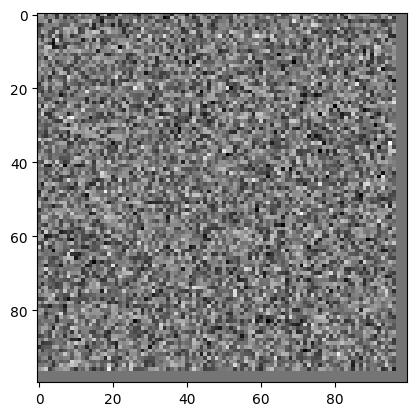

In [ ]:
plt.imshow(I_back[:, :, 0] / np.max(I_back + 1))
plt.show()


## 1.2. Слой Пулинга

Посмотрим на пулинг с точки зрения обработки изображений

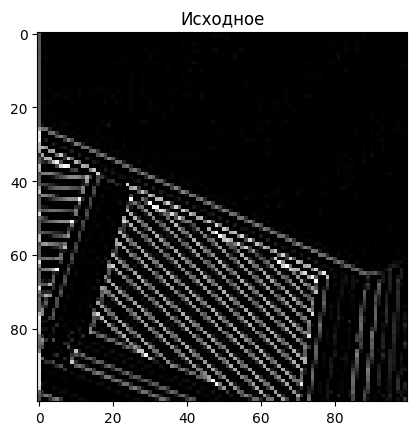

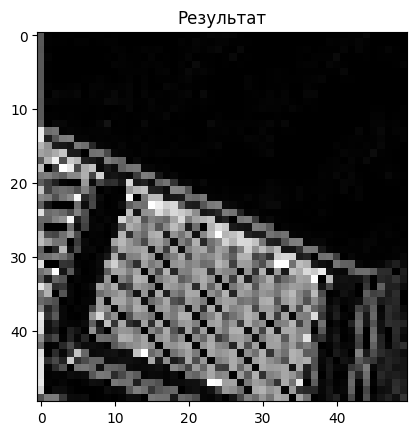

In [ ]:
new_x = int(size_x / 2)
new_y = int(size_y / 2)
# создаем изображение для накопрения результатов пулинга
newImage = np.zeros((new_x, new_y))
for x in range(0, size_x, 2):
    for y in range(0, size_y, 2):
        # вычисляем один пиксель
        pixels = []
        pixels.append(i_transformed[x, y])
        pixels.append(i_transformed[x + 1, y])
        pixels.append(i_transformed[x, y + 1])
        pixels.append(i_transformed[x + 1, y + 1])
        newImage[int(x / 2), int(y / 2)] = max(pixels)

# исходное
plt.gray()
plt.grid(False)
plt.imshow(i_transformed[50:150, :100])
plt.title("Исходное")
# plt.axis('off')
plt.show()

# Plot результирующее изображение
plt.gray()
plt.grid(False)
plt.imshow(newImage[25:75, :50])
plt.title("Результат")
# plt.axis('off')
plt.show()

Содздадим модель слоя пулинга при прямом проходе

In [ ]:
def Maxpool_Forward(image, k=2, s=2):
    # kernel size - k
    # stride  - s
    # image - входное изображение
    h_prev, w_prev, n_c = image.shape

    # Определим размер выхода слоя
    h = int((h_prev - k) / s) + 1
    w = int((w_prev - k) / s) + 1

    # создадим выходной тензор.

    MaxPool_ = np.zeros((h, w, n_c))

    # скользим по каналам тензора
    for i in range(n_c):
        y = out_y = 0
        # вертикально
        while y + k <= h_prev:
            x = out_x = 0
            # горизонтально
            while x + k <= w_prev:
                # выбрали максимальное значение
                MaxPool_[out_y, out_x, i] = np.max(image[y : y + k, x : x + k, i])
                x += s
                out_x += 1
            y += s
            out_y += 1
    return MaxPool_

Обратьный проход по пулингу

In [ ]:
def Maxpool_Backprop(I_pool_inp=None, delta_pool_prev=None, k=2, s=2):
    # kernel size - k
    # stride  - s

    h_prev, w_prev, n_c = I_pool_inp.shape
    h_, w_, n_d = delta_pool_prev.shape
    # Определим размер выхода слоя
    h = h_prev
    w = w_prev

    # создадим выходной тензор.
    dout = np.zeros((h_prev, w_prev, n_c))

    # скользим по каналам тензора
    for i in range(n_c):
        y = out_y = 0
        # вертикально

        while out_y + k <= h_prev:
            x = out_x = 0
            # горизонтально

            while out_x + k <= w_prev:
                # выбрали максимальное значение (берем его координаты в выдленном куске входной картинки
                imax = np.argmax(I_pool_inp[out_y : out_y + k, out_x : out_x + k, i])
                # print(imax)
                # maxPooling
                if np.isscalar(imax):
                    ind = np.unravel_index(
                        np.argmax(I_pool_inp[out_y : out_y + k, out_x : out_x + k, i]),
                        I_pool_inp[out_y : out_y + k, out_x : out_x + k, i].shape,
                    )
                    # добавляем дельту только в максимум (если средний, то добавим всем элементам без поиска максимума во входной картинке
                    dout[out_y + ind[0], out_x + ind[1], i] += delta_pool_prev[y, x]
                    # print(out_y+ind[0], out_x+ind[1],dout[out_y+ind[0], out_x+ind[1], i] )
                # AveragPooling
                # dout[out_y:out_y+k, out_x:out_x+k, i]  = delta_pool_prev[y,x]
                # SumPooling
                # dout[out_y:out_y+k, out_x:out_x+k, i]  = delta_pool_prev[y,x]/k**2
                x += 1
                out_x += s
            y += 1
            out_y += s
    return dout

Посмотрим как сработал пулинг

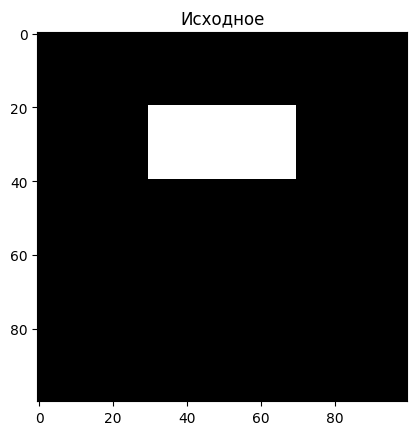

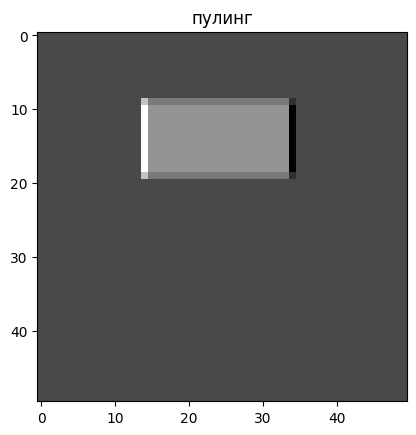

In [ ]:
I = np.zeros((100, 100, 1))

I[20:40, 30:70, 0] = 1

I_max_pool = Maxpool_Forward(I_[2, :, :].reshape((100, 100, 1)), k=2, s=2)

plt.imshow(I[:, :, 0])
plt.title("Исходное")
plt.show()

plt.imshow(I_max_pool[:, :, 0] / np.max(I_max_pool + 1))
plt.title("пулинг")
plt.show()

Запустим обратное распространение по пулингу

In [ ]:
It = I_max_pool.reshape((50, 50, 1)) + np.random.random((50, 50, 1)) * 1 - 0.5

Loss_e = It - I_max_pool


dI_back = Maxpool_Backprop(
    I_pool_inp=I_[0, :, :].reshape((100, 100, 1)), delta_pool_prev=Loss_e, k=2, s=2
)

Посмотрим как сработало

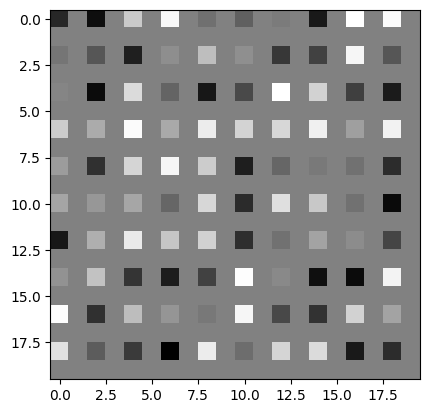

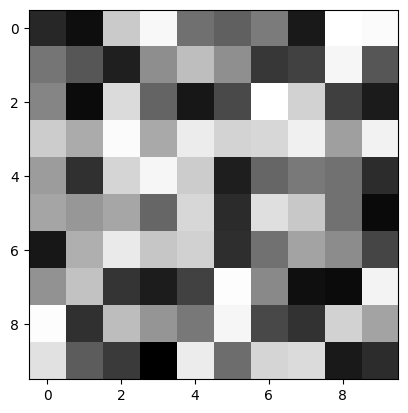

In [ ]:
plt.imshow(dI_back[:20, :20, 0] / np.max(dI_back + 1))
plt.show()
plt.imshow(Loss_e[:10, :10, 0] / np.max(Loss_e + 1))
plt.show()


## 1.3. Слой обратной свертки

In [ ]:
import tensorflow as tf


def test_conv2d_transpose():
    # входной пакет = (1, 2, 2, 1) -> (batch_size, height, width, channels) - 2x2x1 одна картинка в пакете
    x = tf.constant(np.array([[[[1], [2]], [[3], [4]]]]), tf.float32)

    # форма = (3, 3, 1, 1) -> (height, width, input_channels, output_channels) - 3x3x1 фильтр
    f = tf.constant(
        np.array([[[[1]], [[1]], [[1]]], [[[1]], [[1]], [[1]]], [[[1]], [[1]], [[1]]]]),
        tf.float32,
    )

    conv = tf.nn.conv2d_transpose(
        x, f, output_shape=(1, 4, 4, 1), strides=[1, 2, 2, 1], padding="SAME"
    )
    # для TF 1.14
    # with tf.Session() as session:
    #    result = session.run(conv)
    # TF 2.0
    result = conv.numpy()
    return result

Посмотрим результат обратной свертки

In [ ]:
res = test_conv2d_transpose()
res.reshape((4, 4))


array([[ 1.,  1.,  3.,  2.],
       [ 1.,  1.,  3.,  2.],
       [ 4.,  4., 10.,  6.],
       [ 3.,  3.,  7.,  4.]], dtype=float32)

## 1.4 Пакетная нормализация

In [ ]:
# необходимые пакеты
import matplotlib.pyplot as plt
import seaborn

import numpy as np
import pandas as pd

https://kratzert.github.io/2016/02/12/understanding-the-gradient-flow-through-the-batch-normalization-layer.html

In [ ]:
def batchnorm_forward(x, gamma, beta, eps):
    N, D = x.shape

    # 1: вычислим среднее
    mu = 1.0 / N * np.sum(x, axis=0)
    # 2: центрируем тензоры по каждому признаку
    xmu = x - mu
    # 3: считаем квадрат отклонений
    sq = xmu**2
    # 4: дисперсия
    var = 1.0 / N * np.sum(sq, axis=0)
    # 5: добавим еще чуть-чуть для корректных расчетов потом и найдем корень
    sqrtvar = np.sqrt(var + eps)
    # 6: определим обратную величину к сигма
    ivar = 1.0 / sqrtvar
    # 7: вычислим новую варианцию
    xhat = xmu * ivar
    # 8: поднимаем уровень по Гамме
    gammax = gamma * xhat
    # 9: выход модели
    out = gammax + beta
    # сохраним все, что сделали
    cache = (xhat, gamma, xmu, ivar, sqrtvar, var, eps, mu)
    return out, cache

In [ ]:
def batchnorm_backward(dout, cache):
    # достаем из cache все данные о том как был обработан тензор
    xhat, gamma, xmu, ivar, sqrtvar, var, eps, mu = cache

    # gвычисляем размер входа и выхода
    N, D = dout.shape

    # 9 : вычисляем производные для параметров (бетта )
    dbeta = np.sum(dout, axis=0)
    # 8 : Вычислим производную для гаммы
    dgammax = dout
    dgamma = np.sum(dgammax * xhat, axis=0)
    dxhat = dgammax * gamma

    # 7 :
    divar = np.sum(dxhat * xmu, axis=0)
    dxmu1 = dxhat * ivar

    # 6 :
    dsqrtvar = -1.0 / (sqrtvar**2) * divar

    # 5 :
    dvar = 0.5 * 1.0 / np.sqrt(var + eps) * dsqrtvar

    # 4 :
    dsq = 1.0 / N * np.ones((N, D)) * dvar

    # 3 :
    dxmu2 = 2 * xmu * dsq

    # 2 :
    dx1 = dxmu1 + dxmu2
    dmu = -1 * np.sum(dxmu1 + dxmu2, axis=0)

    # 1 :
    dx2 = 1.0 / N * np.ones((N, D)) * dmu

    # 0 :
    dx = dx1 + dx2

    return dx, dgamma, dbeta


In [ ]:
N = 10
D = 3

tensor_input = np.random.random((N, D)) / 2
tensor_input[(N // 2) :, :] += 0.5
print(tensor_input[0, :], tensor_input[-1, :])

[0.06442247 0.04494878 0.15581604] [0.67624491 0.71036708 0.72495988]


In [ ]:
tensor_out, cache = batchnorm_forward(tensor_input, 0.3, 0.5, 0.001)
print("до: ", tensor_input[0, :], "    после: ", tensor_out[0, :])
print("до: ", tensor_input[-1, :], "    после: ", tensor_out[-1, :])
print("mu: ", cache[7], "\nsigma: ", cache[5])

до:  [0.06442247 0.04494878 0.15581604]     после:  [0.04470174 0.08472203 0.16997927]
до:  [0.67624491 0.71036708 0.72495988]     после:  [0.69468988 0.67151391 0.93150258]
mu:  [0.49298674 0.51587138 0.40246544] 
sigma:  [0.07874114 0.11473476 0.04927131]


In [ ]:
dout = np.random.random((N, D)) / 10
dx, dgamma, dbeta = batchnorm_backward(dout, cache)
print("dx: ", dx[0, :])
print("dgamma: ", dgamma)
print("dbeta: ", dbeta)

dx:  [-0.00248891 -0.02014322 -0.01742495]
dgamma:  [0.1478738  0.11342066 0.03711108]
dbeta:  [0.34295847 0.39796207 0.47221295]


## 1.6. Активационные функции

In [ ]:
from IPython.display import Image

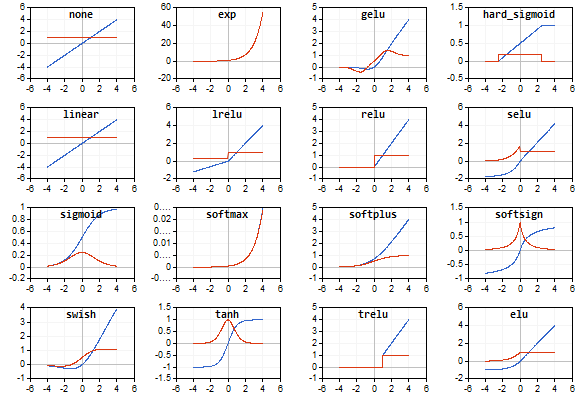

In [ ]:
Image(filename="1.png", width=900)

In [ ]:
# необходимые пакеты для tensorflow
# import matplotlib.pyplot as plt
# import seaborn

# import numpy as np
# import pandas as pd

# from tensorflow.keras.models import Model
# from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10
# from tensorflow.keras.layers import (
#     Dense,
#     Flatten,
#     Input,
#     AveragePooling2D,
#     Conv2DTranspose,
#     Activation,
#     MaxPooling2D,
#     Conv2D,
#     BatchNormalization,
# )
# from tensorflow.keras import backend as K
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras import utils
# # from google.colab import files

# from tensorflow.keras.preprocessing import image
# import numpy as np

# from PIL import Image
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

In [1]:
# необходимые пакеты
import matplotlib.pyplot as plt
import seaborn

import numpy as np
import pandas as pd

from torch.nn import Module

from torch.nn import (
    Linear,
    Flatten,
    Conv2d,
    AvgPool2d,
    ConvTranspose2d,
    ReLU,Sigmoid,
    MaxPool2d,
    BatchNorm2d,
)
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import torch
from torch import nn
from torch import optim

import numpy as np

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**MNIST**

Строим данные для сверточной сети

In [2]:
transfor_gray = torchvision.transforms.Compose([transforms.ToTensor(),])

In [3]:
# загрузка тренировочных и тестовых данных
train_dataset = torchvision.datasets.MNIST(root='data/',
                                             train=True,
                                             transform=transfor_gray,
                                             download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=64,
                                           shuffle=True)
batch_size_test = 8
test_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transfor_gray)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test,
                                         shuffle=False)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:27<00:00, 366kB/s]


Extracting data/MNIST\raw\train-images-idx3-ubyte.gz to data/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 294kB/s]


Extracting data/MNIST\raw\train-labels-idx1-ubyte.gz to data/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.55MB/s]


Extracting data/MNIST\raw\t10k-images-idx3-ubyte.gz to data/MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.12MB/s]

Extracting data/MNIST\raw\t10k-labels-idx1-ubyte.gz to data/MNIST\raw



данные

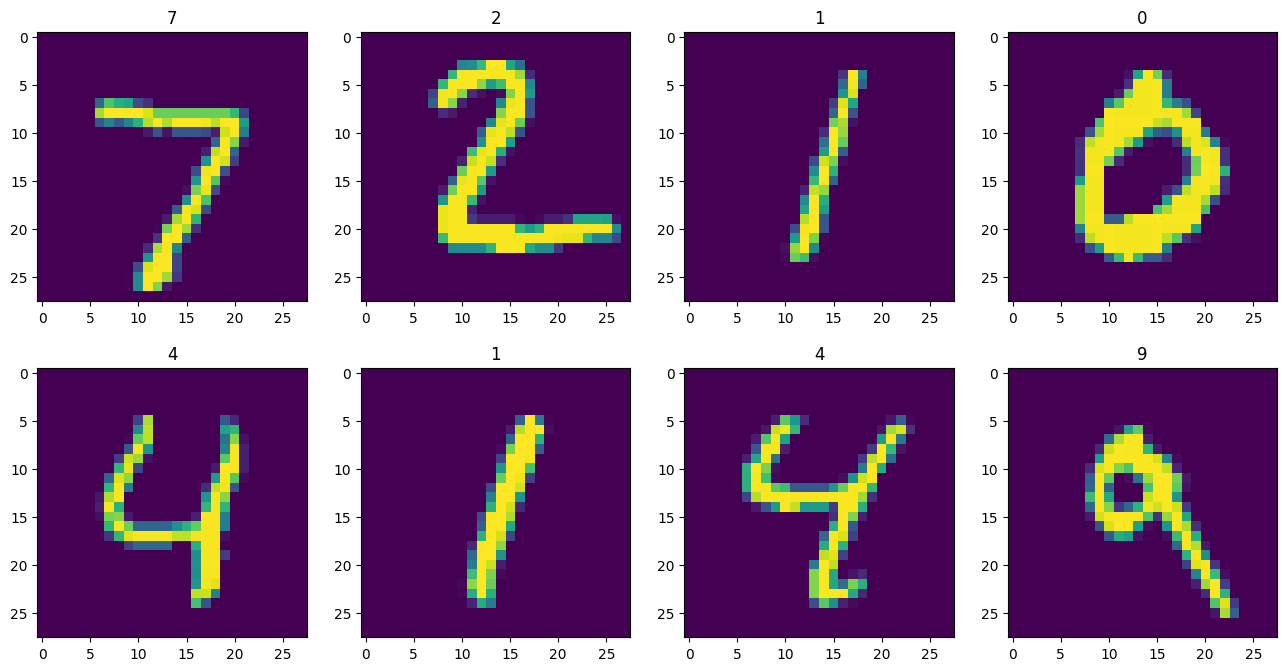

In [4]:
for data in test_loader:
    break

n, k = 4, batch_size_test // 4 + 1 * int((batch_size_test % 4)>0)
images = data[0].cpu().numpy()
labels = data[1].cpu().numpy()
fig, ax = plt.subplots(k, n, figsize=(n*4, 4*k))
for ki in range(k):
    for ni in range(n):
        try:
            im = images[ni + ki*4, 0,  :,:]
            label = labels[ni + ki*4]
            ax[ki, ni].imshow(im)
            ax[ki, ni].set_title(str(label))
        except:
            pass


In [5]:
device = "cuda" if  torch.cuda.is_available() else "cpu"

Нейросеть

Многослойный перцептрон со слоем softmax

In [6]:
class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 8 * hidden_dim)
        self.fc2 = nn.Linear(8 * hidden_dim, 4 * hidden_dim)
        self.fc3 = nn.Linear(4 * hidden_dim, 2 * hidden_dim)
        self.fc4 = nn.Linear(2 * hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, output_dim)


    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = self.fc1(x)
        x = F.leaky_relu(x)
        x = self.fc2(x)
        x = F.leaky_relu(x)
        x = self.fc3(x)
        x = F.leaky_relu(x)
        x = self.fc4(x)
        x = F.leaky_relu(x)
        x = self.fc5(x)
        return torch.nn.functional.softmax(x)

mlp = Net(input_dim=28*28,hidden_dim=1, output_dim=10).to(device)
print(mlp)

Net(
  (fc1): Linear(in_features=784, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=2, bias=True)
  (fc4): Linear(in_features=2, out_features=1, bias=True)
  (fc5): Linear(in_features=1, out_features=10, bias=True)
)


Сверточная нейросеть

In [7]:
class NetC(nn.Module):

    def __init__(self, output_dim, input_dim=1):
        super(NetC, self).__init__()
        self.dp_one = nn.Dropout(0.2)
        self.dp_two = nn.Dropout(0.2)

        self.bn_one = torch.nn.BatchNorm2d(input_dim)
        self.conv_one = torch.nn.Conv2d(input_dim, 30, 3)#30
        self.bn_two = torch.nn.BatchNorm2d(30)
        self.conv_two = torch.nn.Conv2d(30, 60, 3)#
        self.bn_three = torch.nn.BatchNorm2d(60)
        self.conv_three = torch.nn.Conv2d(60, 120, 3)
        self.bn_four = torch.nn.BatchNorm2d(120)
        self.fc1 = torch.nn.Linear(120, 200)
        self.fc2 = torch.nn.Linear(200, 60)
        self.out = torch.nn.Linear(60, output_dim)

    def forward(self, x):
        x = self.bn_one(x)# 28x28x3
        x = self.conv_one(x)#26x26x30
        x = F.relu(x)
        x = F.max_pool2d(x, 2)#30x13x13

        x = self.bn_two(x)
        x = self.conv_two(x)#60 x 11x11
        x = F.relu(x)
        x = F.max_pool2d(x, 2)#60 x 5 x 5

        x = self.bn_three(x)
        x = self.conv_three(x)#120 x 3 x 3
        x = F.leaky_relu(x, 0.1)
        x = F.max_pool2d(x, 2) #120 x 1 x 1

        x = self.bn_four(x)
        x = x.view(x.size(0), -1) # 120 x 1
        x = self.dp_one(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp_two(x)
        x = self.fc2(x)
        x = F.relu(x)
        return self.out(x)

net = NetC(output_dim=10).to(device)
print(net)

NetC(
  (dp_one): Dropout(p=0.2, inplace=False)
  (dp_two): Dropout(p=0.2, inplace=False)
  (bn_one): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_one): Conv2d(1, 30, kernel_size=(3, 3), stride=(1, 1))
  (bn_two): BatchNorm2d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_two): Conv2d(30, 60, kernel_size=(3, 3), stride=(1, 1))
  (bn_three): BatchNorm2d(60, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_three): Conv2d(60, 120, kernel_size=(3, 3), stride=(1, 1))
  (bn_four): BatchNorm2d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=120, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=10, bias=True)
)


Оптимизатор

In [8]:
# for convoution net
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
# for MLP
optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=0.01)

criterion = nn.CrossEntropyLoss()

In [9]:
num_epochs = 5
mlp.train()

for epoch in range(num_epochs):
    running_loss, running_items, running_right = 0.0, 0.0, 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        # обнуляем градиент
        optimizer_mlp.zero_grad()

        outputs = mlp(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_mlp.step()

        # выводим статистику о процессе обучения
        running_loss += loss.item()
        running_items += len(labels)
        running_right += (labels == torch.max(outputs, 1)[1]).sum()

        # выводим статистику о процессе обучения
        if i % 300 == 0:    # печатаем каждые 300 mini-batches
            mlp.eval()

            print(f'Epoch [{epoch + 1}/{num_epochs}]. ' \
                  f'Step [{i + 1}/{len(train_loader)}]. ' \
                  f'Loss: {running_loss / running_items:.3f}. ' \
                  f'Acc: {running_right / running_items:.3f}', end='. ')
            running_loss, running_items, running_right = 0.0, 0.0, 0.0

            test_running_right, test_running_total = 0.0, 0.0
            for i, data in enumerate(test_loader):

                test_outputs = mlp(data[0].to(device))
                test_running_total += len(data[1])
                test_running_right += (data[1].to(device) == torch.max(test_outputs, 1)[1]).sum()

            print(f'Test acc: {test_running_right / test_running_total:.3f}')

        mlp.train()

print('Training is finished!')

C:\Users\User\AppData\Local\Temp\ipykernel_15940\2156362954.py:22: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return torch.nn.functional.softmax(x)


Epoch [1/5]. Step [1/938]. Loss: 0.036. Acc: 0.125. Test acc: 0.101
Epoch [1/5]. Step [301/938]. Loss: 0.034. Acc: 0.274. Test acc: 0.371
Epoch [1/5]. Step [601/938]. Loss: 0.032. Acc: 0.425. Test acc: 0.465
Epoch [1/5]. Step [901/938]. Loss: 0.031. Acc: 0.481. Test acc: 0.506
Epoch [2/5]. Step [1/938]. Loss: 0.030. Acc: 0.578. Test acc: 0.506
Epoch [2/5]. Step [301/938]. Loss: 0.031. Acc: 0.509. Test acc: 0.523
Epoch [2/5]. Step [601/938]. Loss: 0.030. Acc: 0.533. Test acc: 0.554
Epoch [2/5]. Step [901/938]. Loss: 0.030. Acc: 0.564. Test acc: 0.574
Epoch [3/5]. Step [1/938]. Loss: 0.028. Acc: 0.688. Test acc: 0.604
Epoch [3/5]. Step [301/938]. Loss: 0.030. Acc: 0.591. Test acc: 0.619
Epoch [3/5]. Step [601/938]. Loss: 0.029. Acc: 0.637. Test acc: 0.619
Epoch [3/5]. Step [901/938]. Loss: 0.029. Acc: 0.651. Test acc: 0.674
Epoch [4/5]. Step [1/938]. Loss: 0.029. Acc: 0.672. Test acc: 0.672
Epoch [4/5]. Step [301/938]. Loss: 0.029. Acc: 0.660. Test acc: 0.672
Epoch [4/5]. Step [601/938].

In [10]:
inputs.shape

torch.Size([32, 1, 28, 28])

In [11]:
num_epochs = 5
net.train()

for epoch in range(num_epochs):
    running_loss, running_items, running_right = 0.0, 0.0, 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        # обнуляем градиент
        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # выводим статистику о процессе обучения
        running_loss += loss.item()
        running_items += len(labels)
        running_right += (labels == torch.max(outputs, 1)[1]).sum()

        # выводим статистику о процессе обучения
        if i % 300 == 0:    # печатаем каждые 300 mini-batches
            net.eval()

            print(f'Epoch [{epoch + 1}/{num_epochs}]. ' \
                  f'Step [{i + 1}/{len(train_loader)}]. ' \
                  f'Loss: {running_loss / running_items:.3f}. ' \
                  f'Acc: {running_right / running_items:.3f}', end='. ')
            running_loss, running_items, running_right = 0.0, 0.0, 0.0

            test_running_right, test_running_total = 0.0, 0.0
            for i, data in enumerate(test_loader):

                test_outputs = net(data[0].to(device))
                test_running_total += len(data[1])
                test_running_right += (data[1].to(device) == torch.max(test_outputs, 1)[1]).sum()

            print(f'Test acc: {test_running_right / test_running_total:.3f}')

        mlp.train()

print('Training is finished!')

Epoch [1/5]. Step [1/938]. Loss: 0.036. Acc: 0.109. Test acc: 0.096
Epoch [1/5]. Step [301/938]. Loss: 0.005. Acc: 0.900. Test acc: 0.959
Epoch [1/5]. Step [601/938]. Loss: 0.002. Acc: 0.958. Test acc: 0.964
Epoch [1/5]. Step [901/938]. Loss: 0.002. Acc: 0.965. Test acc: 0.973
Epoch [2/5]. Step [1/938]. Loss: 0.004. Acc: 0.953. Test acc: 0.969
Epoch [2/5]. Step [301/938]. Loss: 0.002. Acc: 0.969. Test acc: 0.969
Epoch [2/5]. Step [601/938]. Loss: 0.002. Acc: 0.971. Test acc: 0.974
Epoch [2/5]. Step [901/938]. Loss: 0.002. Acc: 0.975. Test acc: 0.978
Epoch [3/5]. Step [1/938]. Loss: 0.006. Acc: 0.922. Test acc: 0.977
Epoch [3/5]. Step [301/938]. Loss: 0.002. Acc: 0.976. Test acc: 0.975
Epoch [3/5]. Step [601/938]. Loss: 0.001. Acc: 0.979. Test acc: 0.978
Epoch [3/5]. Step [901/938]. Loss: 0.001. Acc: 0.978. Test acc: 0.978
Epoch [4/5]. Step [1/938]. Loss: 0.000. Acc: 1.000. Test acc: 0.980
Epoch [4/5]. Step [301/938]. Loss: 0.001. Acc: 0.979. Test acc: 0.973
Epoch [4/5]. Step [601/938].

Посмотреть на внутренние слои через дополнительные модели:

- x1 - 1я нормализация
- x2 - 1-я свертка
- x3 - 2-я нормализация
- x4 - 1-й пулинг
- x5 - 3-я свертка

In [12]:
class NetC(nn.Module):

    def __init__(self, output_dim, input_dim=1):
        super(NetC, self).__init__()
        self.dp_one = nn.Dropout(0.2)
        self.dp_two = nn.Dropout(0.2)

        self.bn_one = torch.nn.BatchNorm2d(input_dim)
        self.conv_one = torch.nn.Conv2d(input_dim, 30, 3)#30
        self.bn_two = torch.nn.BatchNorm2d(30)
        self.conv_two = torch.nn.Conv2d(30, 60, 3)#
        self.bn_three = torch.nn.BatchNorm2d(60)
        self.conv_three = torch.nn.Conv2d(60, 120, 3)
        self.bn_four = torch.nn.BatchNorm2d(120)
        self.fc1 = torch.nn.Linear(120, 200)
        self.fc2 = torch.nn.Linear(200, 60)
        self.out = torch.nn.Linear(60, output_dim)

    def forward(self, x):
        x1 = self.bn_one(x)# 28x28x3
        x = x1
        x = self.conv_one(x)#26x26x30
        x = F.relu(x)
        x2 = x
        x = F.max_pool2d(x, 2)#30x13x13
        x4 = x

        x = self.bn_two(x)
        x3 = x
        x = self.conv_two(x)#60 x 11x11
        x = F.relu(x)
        x = F.max_pool2d(x, 2)#60 x 5 x 5

        x = self.bn_three(x)
        x = self.conv_three(x)#120 x 3 x 3
        x = F.leaky_relu(x, 0.1)
        x5 = x
        x = F.max_pool2d(x, 2) #120 x 1 x 1

        x = self.bn_four(x)
        x = x.view(x.size(0), -1) # 120 x 1
        x = self.dp_one(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp_two(x)
        x = self.fc2(x)
        x = F.relu(x)
        return self.out(x), x1, x2, x3, x4, x5

net = NetC(output_dim=10).to(device)
print(net)
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)

NetC(
  (dp_one): Dropout(p=0.2, inplace=False)
  (dp_two): Dropout(p=0.2, inplace=False)
  (bn_one): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_one): Conv2d(1, 30, kernel_size=(3, 3), stride=(1, 1))
  (bn_two): BatchNorm2d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_two): Conv2d(30, 60, kernel_size=(3, 3), stride=(1, 1))
  (bn_three): BatchNorm2d(60, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_three): Conv2d(60, 120, kernel_size=(3, 3), stride=(1, 1))
  (bn_four): BatchNorm2d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=120, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=10, bias=True)
)


In [13]:
num_epochs = 5
net.train()

for epoch in range(num_epochs):
    running_loss, running_items, running_right = 0.0, 0.0, 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        # обнуляем градиент
        optimizer.zero_grad()

        outputs, _,_,_,_,_ = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # выводим статистику о процессе обучения
        running_loss += loss.item()
        running_items += len(labels)
        running_right += (labels == torch.max(outputs, 1)[1]).sum()

        # выводим статистику о процессе обучения
        if i % 300 == 0:    # печатаем каждые 300 mini-batches
            net.eval()

            print(f'Epoch [{epoch + 1}/{num_epochs}]. ' \
                  f'Step [{i + 1}/{len(train_loader)}]. ' \
                  f'Loss: {running_loss / running_items:.3f}. ' \
                  f'Acc: {running_right / running_items:.3f}', end='. ')
            running_loss, running_items, running_right = 0.0, 0.0, 0.0

            test_running_right, test_running_total = 0.0, 0.0
            for i, data in enumerate(test_loader):

                test_outputs, x1,x2,x3,x4,x5 = net(data[0].to(device))
                test_running_total += len(data[1])
                test_running_right += (data[1].to(device) == torch.max(test_outputs, 1)[1]).sum()

            print(f'Test acc: {test_running_right / test_running_total:.3f}')

        net.train()

print('Training is finished!')

Epoch [1/5]. Step [1/938]. Loss: 0.036. Acc: 0.094. Test acc: 0.103
Epoch [1/5]. Step [301/938]. Loss: 0.004. Acc: 0.918. Test acc: 0.968
Epoch [1/5]. Step [601/938]. Loss: 0.003. Acc: 0.956. Test acc: 0.978
Epoch [1/5]. Step [901/938]. Loss: 0.002. Acc: 0.964. Test acc: 0.968
Epoch [2/5]. Step [1/938]. Loss: 0.005. Acc: 0.906. Test acc: 0.970
Epoch [2/5]. Step [301/938]. Loss: 0.002. Acc: 0.970. Test acc: 0.979
Epoch [2/5]. Step [601/938]. Loss: 0.002. Acc: 0.974. Test acc: 0.978
Epoch [2/5]. Step [901/938]. Loss: 0.002. Acc: 0.971. Test acc: 0.981
Epoch [3/5]. Step [1/938]. Loss: 0.001. Acc: 0.969. Test acc: 0.980
Epoch [3/5]. Step [301/938]. Loss: 0.002. Acc: 0.974. Test acc: 0.980
Epoch [3/5]. Step [601/938]. Loss: 0.002. Acc: 0.974. Test acc: 0.985
Epoch [3/5]. Step [901/938]. Loss: 0.001. Acc: 0.977. Test acc: 0.982
Epoch [4/5]. Step [1/938]. Loss: 0.000. Acc: 1.000. Test acc: 0.982
Epoch [4/5]. Step [301/938]. Loss: 0.001. Acc: 0.981. Test acc: 0.970
Epoch [4/5]. Step [601/938].

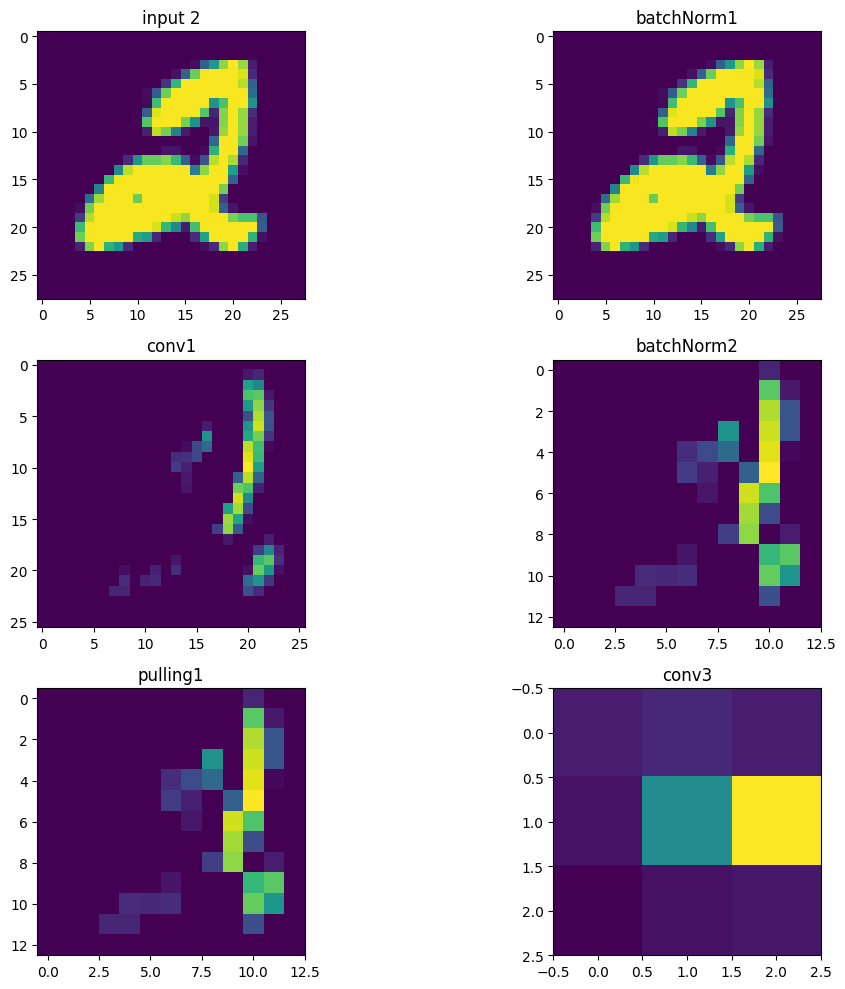

In [14]:
test_outputs, x1,x2,x3,x4,x5 = net(data[0].to(device))
label =  data[1]
m0 =  2

fig = plt.figure(figsize=(12, 10)) # Increased figure size for better spacing

g1 = x1[m0, 0, :, :].cpu().detach().numpy()
plt.subplot(322)
plt.imshow(g1)
plt.title("batchNorm1")

g1 = data[0][m0, 0, :, :].cpu().detach().numpy()
plt.subplot(321)
plt.imshow(g1)
plt.title("input " + str(label[m0].item()))
g1 =  x2[m0, 0, :, :].cpu().detach().numpy()

plt.subplot(323)
plt.imshow(g1)
plt.title("conv1")

g1 =  x3[m0, 0, :, :].cpu().detach().numpy()
plt.subplot(324)
plt.title("batchNorm2")
plt.imshow(g1)

g1 =  x4[m0, 0, :, :].cpu().detach().numpy()
plt.subplot(325)
plt.imshow(g1)
plt.title("pulling1")

g1 =  x5[m0, 0, :, :].cpu().detach().numpy()
plt.subplot(326)
plt.imshow(g1)
plt.title("conv3")
plt.tight_layout() # Automatically adjusts subplot params for a tight layout
plt.show()

In [18]:
transfor_rgb = torchvision.transforms.Compose([transforms.Resize(28),
                                       transforms.ToTensor(),
                                       transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                            std=[0.229, 0.224, 0.225])])
train_dataset = torchvision.datasets.CIFAR10(root='data/',
                                             train=True,
                                             transform=transfor_rgb,
                                             download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=64,
                                           shuffle=True)

batch_size_test = 8
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transfor_rgb)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test,
                                         shuffle=False)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:15<00:00, 11.0MB/s]


Extracting data/cifar-10-python.tar.gz to data/
Files already downloaded and verified


[An Interactive Node-Link Visualization of Convolutional Neural Networks](https://adamharley.com/nn_vis/)

## Задание 1.

1.1 адаптировать модель к набору данных CIFAR10

1.2 провести обучение - получить результаты (создать разные сетки - средний пуллинг, максимальный , стек сверток, включать нормализацию, включать дропаут)

1.3  собрать результаты - сравнить


## Задание 2

2.1 добавить резидуальный обход

2.2 сделать более глубокую сеть


In [19]:
# необходимые пакеты
import matplotlib.pyplot as plt
import seaborn

import numpy as np
import pandas as pd

from torch.nn import Module

from torch.nn import (
    Linear,
    Flatten,
    Conv2d,
    AvgPool2d,
    ConvTranspose2d,
    ReLU,Sigmoid,
    MaxPool2d,
    BatchNorm2d,
)
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import torch
from torch import nn
from torch import optim

import numpy as np

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
transfor_rgb = torchvision.transforms.Compose([transforms.Resize(28),
                                       transforms.ToTensor(),
                                       transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                            std=[0.229, 0.224, 0.225])])
train_dataset = torchvision.datasets.CIFAR10(root='data/',
                                             train=True,
                                             transform=transfor_rgb,
                                             download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=64,
                                           shuffle=True)

batch_size_test = 8
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transfor_rgb)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test,
                                         shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


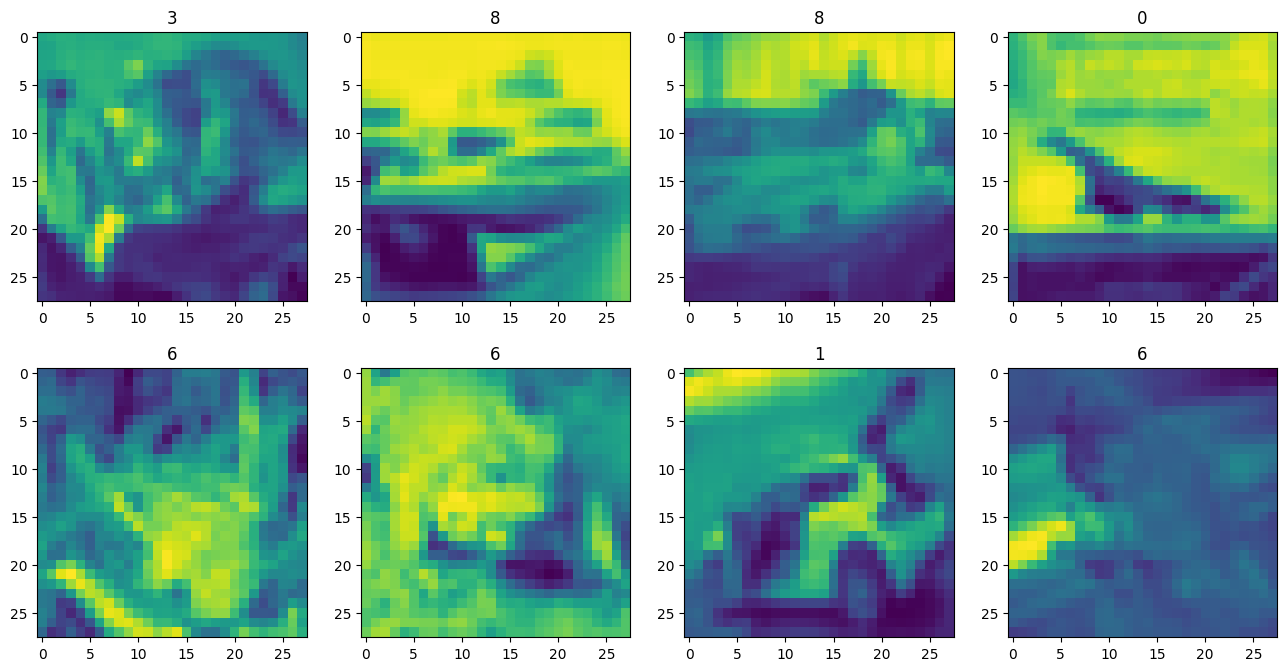

In [21]:
for data in test_loader:
    break

n, k = 4, batch_size_test // 4 + 1 * int((batch_size_test % 4)>0)
images = data[0].cpu().numpy()
labels = data[1].cpu().numpy()
fig, ax = plt.subplots(k, n, figsize=(n*4, 4*k))
for ki in range(k):
    for ni in range(n):
        try:
            im = images[ni + ki*4, 0,  :,:]
            label = labels[ni + ki*4]
            ax[ki, ni].imshow(im)
            ax[ki, ni].set_title(str(label))
        except:
            pass


In [22]:
class NetC(nn.Module):

    def __init__(self, output_dim, input_dim=3,
                 pool_type="max",
                 use_bn=True,
                 use_dropout=True):
        super(NetC, self).__init__()

        self.use_bn = use_bn
        self.use_dropout = use_dropout

        if pool_type == "max":
            self.pool = nn.MaxPool2d(2)
        elif pool_type == "avg":
            self.pool = nn.AvgPool2d(2)
            
        if use_dropout:
            self.dp_one = nn.Dropout(0.5)
            self.dp_two = nn.Dropout(0.5)
        else:
            self.dp_one = nn.Identity()
            self.dp_two = nn.Identity()

        # сверточные слои + BatchNorm
        self.bn_one = nn.BatchNorm2d(input_dim) if use_bn else nn.Identity()
        self.conv_one = nn.Conv2d(input_dim, 30, 3)      # 3x28x28 -> 30x26x26

        self.bn_two = nn.BatchNorm2d(30) if use_bn else nn.Identity()
        self.conv_two = nn.Conv2d(30, 60, 3)             # 30x13x13 -> 60x11x11

        self.bn_three = nn.BatchNorm2d(60) if use_bn else nn.Identity()
        self.conv_three = nn.Conv2d(60, 120, 3)          # 60x5x5 -> 120x3x3

        self.bn_four = nn.BatchNorm2d(120) if use_bn else nn.Identity()

        # полносвязные слои
        self.fc1 = nn.Linear(120, 200)
        self.fc2 = nn.Linear(200, 60)
        self.out = nn.Linear(60, output_dim)

    def forward(self, x):
        # 3x28x28
        x = self.bn_one(x)
        x = self.conv_one(x)             # 30x26x26
        x = F.relu(x)
        x = self.pool(x)                 # 30x13x13

        x = self.bn_two(x)
        x = self.conv_two(x)             # 60x11x11
        x = F.relu(x)
        x = self.pool(x)                 # 60x5x5

        x = self.bn_three(x)
        x = self.conv_three(x)           # 120x3x3
        x = F.leaky_relu(x, 0.1)
        x = self.pool(x)                 # 120x1x1

        x = self.bn_four(x)
        x = x.view(x.size(0), -1)        # 120
        x = self.dp_one(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp_two(x)
        x = self.fc2(x)
        x = F.relu(x)
        return self.out(x)


In [23]:
class NetCStacked(nn.Module):
    def __init__(self, output_dim, input_dim=3,
                 pool_type="max",
                 use_bn=True,
                 use_dropout=True):
        super(NetCStacked, self).__init__()

        self.use_bn = use_bn
        self.use_dropout = use_dropout

        if pool_type == "max":
            self.pool = nn.MaxPool2d(2)
        elif pool_type == "avg":
            self.pool = nn.AvgPool2d(2)

        def bn(c):
            return nn.BatchNorm2d(c) if use_bn else nn.Identity()

        self.conv1_1 = nn.Conv2d(input_dim, 32, 3, padding=1)  # 3x28x28 -> 32x28x28
        self.bn1_1 = bn(32)
        self.conv1_2 = nn.Conv2d(32, 32, 3, padding=1)         # 32x28x28
        self.bn1_2 = bn(32)

        self.conv2_1 = nn.Conv2d(32, 64, 3, padding=1)         # 32x14x14 -> 64x14x14
        self.bn2_1 = bn(64)
        self.conv2_2 = nn.Conv2d(64, 64, 3, padding=1)         # 64x14x14
        self.bn2_2 = bn(64)

        self.conv3_1 = nn.Conv2d(64, 128, 3, padding=1)        # 64x7x7 -> 128x7x7
        self.bn3_1 = bn(128)
        self.conv3_2 = nn.Conv2d(128, 128, 3, padding=1)       # 128x7x7
        self.bn3_2 = bn(128)

        if use_dropout:
            self.dp = nn.Dropout(0.5)
        else:
            self.dp = nn.Identity()

        # после трёх пуллингов: 28 -> 14 -> 7 -> 3
        self.fc = nn.Linear(128 * 3 * 3, output_dim)

    def forward(self, x):
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool(x)          # 32x14x14

        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool(x)          # 64x7x7

        x = F.relu(self.bn3_1(self.conv3_1(x)))
        x = F.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool(x)          # 128x3x3

        x = x.view(x.size(0), -1)
        x = self.dp(x)
        x = self.fc(x)
        return x


In [24]:
criterion = nn.CrossEntropyLoss()

def train_model(net, optimizer, num_epochs,
                train_loader, test_loader,
                name="model"):
    net.train()
    for epoch in range(num_epochs):
        running_loss, running_items, running_right = 0.0, 0.0, 0.0

        for i, data in enumerate(train_loader):
            inputs, labels = data[0].to(device), data[1].to(device)

            # обнуляем градиент
            optimizer.zero_grad()

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_items += len(labels)
            running_right += (labels == torch.max(outputs, 1)[1]).sum()

            if i % 300 == 0:
                net.eval()
                print(f'{name}. Epoch [{epoch + 1}/{num_epochs}]. '
                      f'Step [{i + 1}/{len(train_loader)}]. '
                      f'Loss: {running_loss / running_items:.3f}. '
                      f'Acc: {running_right / running_items:.3f}', end='. ')

                running_loss, running_items, running_right = 0.0, 0.0, 0.0

                test_running_right, test_running_total = 0.0, 0.0
                test_running_loss = 0.0

                for j, tdata in enumerate(test_loader):
                    tinputs, tlabels = tdata[0].to(device), tdata[1].to(device)
                    toutputs = net(tinputs)
                    tloss = criterion(toutputs, tlabels)
                    test_running_loss += tloss.item()
                    test_running_total += len(tlabels)
                    test_running_right += (tlabels == torch.max(toutputs, 1)[1]).sum()

                print(f'Test loss: {test_running_loss / test_running_total:.3f}. '
                      f'Test acc: {test_running_right / test_running_total:.3f}')

                net.train()

    print(f'Training for {name} is finished!')
    net.eval()
    test_running_right, test_running_total = 0.0, 0.0
    with torch.no_grad():
        for tdata in test_loader:
            tinputs, tlabels = tdata[0].to(device), tdata[1].to(device)
            toutputs = net(tinputs)
            test_running_total += len(tlabels)
            test_running_right += (tlabels == torch.max(toutputs, 1)[1]).sum()
    final_acc = (test_running_right / test_running_total).item()
    print(f'Final test acc for {name}: {final_acc:.3f}')
    return final_acc

In [25]:
results = []

num_epochs = 5

# 1) MaxPooling + BatchNorm + Dropout
net1 = NetC(output_dim=10,
            input_dim=3,
            pool_type="max",
            use_bn=True,
            use_dropout=True).to(device)
print(net1)
optimizer1 = torch.optim.Adam(net1.parameters(), lr=0.001)
acc1 = train_model(net1, optimizer1, num_epochs,
                   train_loader, test_loader,
                   name="NetC_max_BN_DO")
results.append(("maxpool + BN + dropout", acc1))

# 2) AvgPooling + BatchNorm + Dropout
net2 = NetC(output_dim=10,
            input_dim=3,
            pool_type="avg",
            use_bn=True,
            use_dropout=True).to(device)
print(net2)
optimizer2 = torch.optim.Adam(net2.parameters(), lr=0.001)
acc2 = train_model(net2, optimizer2, num_epochs,
                   train_loader, test_loader,
                   name="NetC_avg_BN_DO")
results.append(("avgpool + BN + dropout", acc2))

# 3) MaxPooling + NO BatchNorm + Dropout
net3 = NetC(output_dim=10,
            input_dim=3,
            pool_type="max",
            use_bn=False,
            use_dropout=True).to(device)
print(net3)
optimizer3 = torch.optim.Adam(net3.parameters(), lr=0.001)
acc3 = train_model(net3, optimizer3, num_epochs,
                   train_loader, test_loader,
                   name="NetC_max_noBN_DO")
results.append(("maxpool + no BN + dropout", acc3))

# 4) MaxPooling + BatchNorm + NO Dropout
net4 = NetC(output_dim=10,
            input_dim=3,
            pool_type="max",
            use_bn=True,
            use_dropout=False).to(device)
print(net4)
optimizer4 = torch.optim.Adam(net4.parameters(), lr=0.001)
acc4 = train_model(net4, optimizer4, num_epochs,
                   train_loader, test_loader,
                   name="NetC_max_BN_noDO")
results.append(("maxpool + BN + no dropout", acc4))

# 5) Стек свёрток + MaxPooling + BatchNorm + Dropout
net5 = NetCStacked(output_dim=10,
                   input_dim=3,
                   pool_type="max",
                   use_bn=True,
                   use_dropout=True).to(device)
print(net5)
optimizer5 = torch.optim.Adam(net5.parameters(), lr=0.001)
acc5 = train_model(net5, optimizer5, num_epochs,
                   train_loader, test_loader,
                   name="NetC_stacked_max_BN_DO")
results.append(("stacked conv + maxpool + BN + dropout", acc5))

print("\n========== Сводка результатов по CIFAR10 ==========")
for name, acc in results:
    print(f"{name:40s} | Test acc: {acc:.3f}")

NetC(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dp_one): Dropout(p=0.5, inplace=False)
  (dp_two): Dropout(p=0.5, inplace=False)
  (bn_one): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_one): Conv2d(3, 30, kernel_size=(3, 3), stride=(1, 1))
  (bn_two): BatchNorm2d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_two): Conv2d(30, 60, kernel_size=(3, 3), stride=(1, 1))
  (bn_three): BatchNorm2d(60, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_three): Conv2d(60, 120, kernel_size=(3, 3), stride=(1, 1))
  (bn_four): BatchNorm2d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=120, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=10, bias=True)
)
NetC_max_BN_DO. Epoch [1/5]. Step [1/782]. Loss: 0.036. Acc: 0.141. Test lo

### Что такое Residual Connection?

Суть резидуального обхода заключается в том, что вход слоя или группы слоев напрямую добавляется к выходу этих слоев. Формально, если у нас есть функция $H(x)$, которую слой или блок пытается аппроксимировать, то вместо прямого изучения $H(x)$, блок изучает *резидуум* $F(x) = H(x) - x$. Таким образом, выход блока будет $H(x) = F(x) + x$.

Графически это выглядит как стрелка, которая 'обходит' один или несколько слоев, соединяя вход с выходом, прежде чем результат проходит через функцию активации.

### Зачем нужны Residual Connections?

1.  **Решение проблемы затухания/взрыва градиентов (Vanishing/Exploding Gradients)**: В очень глубоких сетях градиенты при обратном распространении могут либо затухать до нуля, либо взрываться, что делает обучение сети очень сложным. Резидуальные обходы обеспечивают прямой путь для градиентов, позволяя им свободно проходить через сеть и эффективно обновлять веса.

2.  **Облегчение обучения глубоких сетей**: Без резидуальных обходов добавление большего количества слоев в глубокую сеть может привести к ухудшению производительности (даже на обучающей выборке), а не к ее улучшению. Это связано с тем, что оптимизатору становится труднее изучать функцию тождественности (identity function) для дополнительных слоев (т.е., чтобы новые слои просто пропускали вход без изменений). С резидуальным обходом, если новые слои ничего не улучшают, они могут просто изучить $F(x) = 0$, и тогда $H(x) = x$, что гораздо проще.

3.  **Повышение производительности**: За счет более эффективного обучения, сети с резидуальными обходами часто достигают лучшей производительности на различных задачах, особенно в компьютерном зрении.

### Как это выглядит в коде (пример из ноутбука):

В предоставленном коде вы можете увидеть резидуальный обход в классе `NetC`:

```python
        x = self.bn_two(x)
        x3 = x # Сохраняем вход для резидуального обхода
        x = self.conv_two1(x)
        x = F.relu(x)
        x = self.conv_two2(x)
        x = F.relu(x)
        x = x + x3 # Здесь происходит добавление входа (x3) к выходу слоев
        x = self.conv_two3(x)
```

Здесь `x3` сохраняет состояние тензора перед блоком сверток (`conv_two1`, `conv_two2`). После прохождения через эти сверточные слои и активации, оригинальный `x3` добавляется к их выходу (`x = x + x3`), что и является резидуальным обходом.

In [28]:
class NetCResDeep(nn.Module):

    def __init__(self, output_dim, input_dim=3):
        super(NetCResDeep, self).__init__()

        # --- Блок 1: 3 -> 32 канала ---
        self.bn_one = nn.BatchNorm2d(input_dim)
        self.conv1_1 = nn.Conv2d(input_dim, 32, 3, padding=1)
        self.conv1_2 = nn.Conv2d(32, 32, 3, padding=1)
        # Резидуальный путь: проекция 3 -> 32
        self.shortcut1 = nn.Conv2d(input_dim, 32, kernel_size=1)

        # --- Блок 2: 32 -> 64 канала ---
        self.bn_two = nn.BatchNorm2d(32)
        self.conv2_1 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv2_2 = nn.Conv2d(64, 64, 3, padding=1)
        self.shortcut2 = nn.Conv2d(32, 64, kernel_size=1)

        # --- Блок 3: 64 -> 128 каналов ---
        self.bn_three = nn.BatchNorm2d(64)
        self.conv3_1 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3_2 = nn.Conv2d(128, 128, 3, padding=1)
        self.shortcut3 = nn.Conv2d(64, 128, kernel_size=1)

        self.pool = nn.MaxPool2d(2)
        self.bn_four = nn.BatchNorm2d(128)

        self.dp_one = nn.Dropout(0.5)
        self.dp_two = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 64)
        self.out = nn.Linear(64, output_dim)

    def forward(self, x):
        x1 = self.bn_one(x)
        # residual до свёрток: проекция 3->32
        res1 = self.shortcut1(x1)

        x = self.conv1_1(x1)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = F.relu(x)
        x = x + res1
        x2 = x                   # выход блока 1
        x = self.pool(x)         # [B, 32, 14, 14]

        x = self.bn_two(x)
        x3_in = x
        res2 = self.shortcut2(x3_in)

        x = self.conv2_1(x)
        x = F.relu(x)
        x = self.conv2_2(x)
        x = F.relu(x)
        x = x + res2
        x3 = x
        x = self.pool(x)         # [B, 64, 7, 7]

        x = self.bn_three(x)
        x4_in = x
        res3 = self.shortcut3(x4_in)

        x = self.conv3_1(x)
        x = F.relu(x)
        x = self.conv3_2(x)
        x = F.leaky_relu(x, 0.1)
        x = x + res3
        x4 = x
        x = self.pool(x)         # [B, 128, 3, 3]

        x = self.bn_four(x)
        x5 = x

        x = x.view(x.size(0), -1)
        x = self.dp_one(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp_two(x)
        x = self.fc2(x)
        x = F.relu(x)
        logits = self.out(x)

        return logits, x1, x2, x3, x4, x5

net = NetCResDeep(output_dim=10, input_dim=3).to(device)
print(net)

NetCResDeep(
  (bn_one): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (shortcut1): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (bn_two): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (shortcut2): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  (bn_three): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (shortcut3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stri

In [29]:
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs = 5
net.train()

for epoch in range(num_epochs):
    running_loss, running_items, running_right = 0.0, 0.0, 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        # обнуляем градиент
        optimizer.zero_grad()

        outputs, _, _, _, _, _ = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_items += len(labels)
        running_right += (labels == torch.max(outputs, 1)[1]).sum()

        if i % 300 == 0:
            net.eval()

            print(f'Epoch [{epoch + 1}/{num_epochs}]. '
                  f'Step [{i + 1}/{len(train_loader)}]. '
                  f'Loss: {running_loss / running_items:.3f}. '
                  f'Acc: {running_right / running_items:.3f}', end='. ')
            running_loss, running_items, running_right = 0.0, 0.0, 0.0

            test_running_right, test_running_total = 0.0, 0.0
            for j, data_t in enumerate(test_loader):

                test_outputs, x1, x2, x3, x4, x5 = net(data_t[0].to(device))
                test_running_total += len(data_t[1])
                test_running_right += (data_t[1].to(device)
                                       == torch.max(test_outputs, 1)[1]).sum()

            print(f'Test acc: {test_running_right / test_running_total:.3f}')

            net.train()

print('Training is finished!')

Epoch [1/5]. Step [1/782]. Loss: 0.036. Acc: 0.125. Test acc: 0.100
Epoch [1/5]. Step [301/782]. Loss: 0.025. Acc: 0.415. Test acc: 0.525
Epoch [1/5]. Step [601/782]. Loss: 0.020. Acc: 0.529. Test acc: 0.605
Epoch [2/5]. Step [1/782]. Loss: 0.020. Acc: 0.516. Test acc: 0.621
Epoch [2/5]. Step [301/782]. Loss: 0.017. Acc: 0.619. Test acc: 0.668
Epoch [2/5]. Step [601/782]. Loss: 0.016. Acc: 0.647. Test acc: 0.687
Epoch [3/5]. Step [1/782]. Loss: 0.012. Acc: 0.672. Test acc: 0.709
Epoch [3/5]. Step [301/782]. Loss: 0.014. Acc: 0.691. Test acc: 0.726
Epoch [3/5]. Step [601/782]. Loss: 0.013. Acc: 0.710. Test acc: 0.734
Epoch [4/5]. Step [1/782]. Loss: 0.012. Acc: 0.719. Test acc: 0.737
Epoch [4/5]. Step [301/782]. Loss: 0.012. Acc: 0.737. Test acc: 0.754
Epoch [4/5]. Step [601/782]. Loss: 0.012. Acc: 0.742. Test acc: 0.743
Epoch [5/5]. Step [1/782]. Loss: 0.011. Acc: 0.750. Test acc: 0.766
Epoch [5/5]. Step [301/782]. Loss: 0.010. Acc: 0.764. Test acc: 0.772
Epoch [5/5]. Step [601/782]. L

## Аугментация





In [30]:
batch_size_test = 8
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transfor_rgb)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test,
                                         shuffle=False)

Files already downloaded and verified


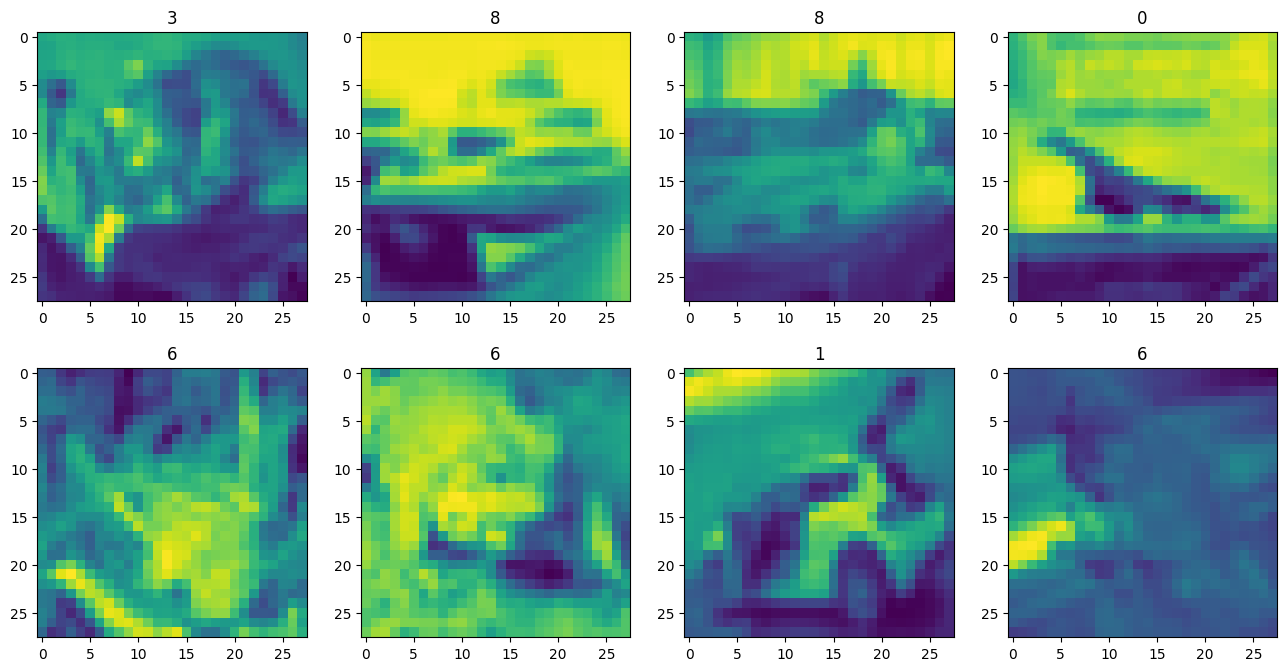

In [31]:
for data in test_loader:
    break

n, k = 4, batch_size_test // 4 + 1 * int((batch_size_test % 4)>0)
images = data[0].cpu().numpy()
labels = data[1].cpu().numpy()
fig, ax = plt.subplots(k, n, figsize=(n*4, 4*k))
for ki in range(k):
    for ni in range(n):
        try:
            im = images[ni + ki*4, 0,  :,:]
            label = labels[ni + ki*4]
            ax[ki, ni].imshow(im)
            ax[ki, ni].set_title(str(label))
        except:
            pass


In [32]:
transfor_rgb = torchvision.transforms.Compose([transforms.Resize(224),
                                               transforms.RandomPerspective(distortion_scale=0.6, p=0.50),
                                       transforms.ToTensor(),
                                       transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                            std=[0.229, 0.224, 0.225])])
batch_size_test = 8
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transfor_rgb)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test,
                                         shuffle=False)

Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7677125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7502832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7851416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24214405..1.6369936].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49901533..1.4079132].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4828431..1.2477095].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952.

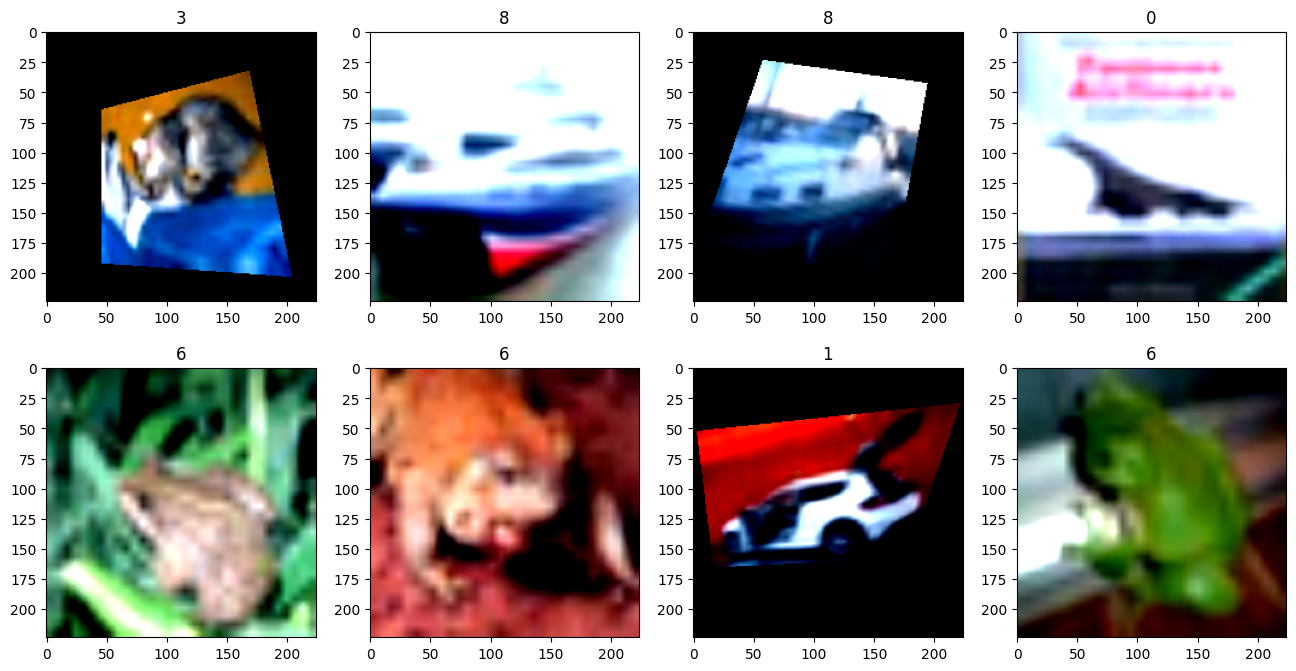

In [33]:
for data in test_loader:
    break

n, k = 4, batch_size_test // 4 + 1 * int((batch_size_test % 4)>0)
images = data[0].cpu().numpy()
labels = data[1].cpu().numpy()
fig, ax = plt.subplots(k, n, figsize=(n*4, 4*k))
for ki in range(k):
    for ni in range(n):
        try:
            im = images[ni + ki*4, :,  :,:].transpose([1,2,0] ) * 0.5 + 0.5
            label = labels[ni + ki*4]
            ax[ki, ni].imshow(im)
            ax[ki, ni].set_title(str(label))
        except:
            pass

## Задание 3

3.1. Сделать аугментации данных

3.2. провести обучение на аугментированных данных

In [34]:
train_transform = transforms.Compose([
    transforms.Resize(28),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                             train=True,
                                             download=True,
                                             transform=train_transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data',
                                            train=False,
                                            download=True,
                                            transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=64,
                                           shuffle=True)

batch_size_test = 8
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=batch_size_test,
                                          shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


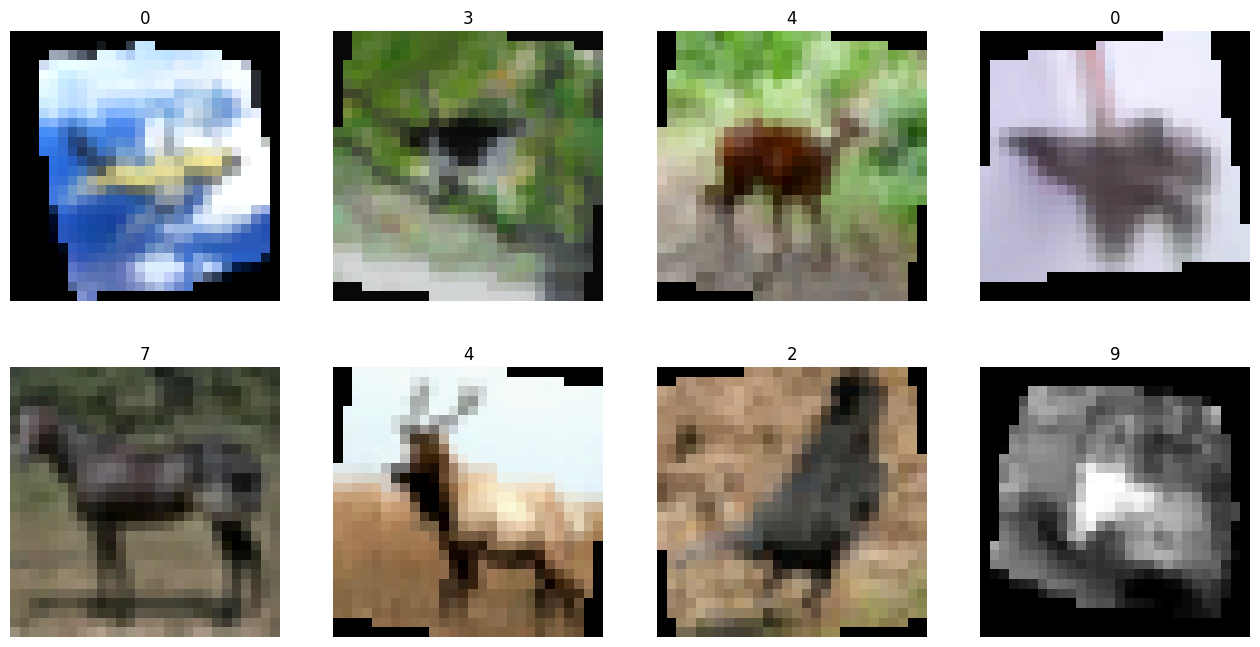

In [37]:
for data in train_loader:
    break

n, k = 4, batch_size_test // 4 + 1 * int((batch_size_test % 4) > 0)
images = data[0].cpu().numpy()
labels = data[1].cpu().numpy()
fig, ax = plt.subplots(k, n, figsize=(n*4, 4*k))

mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
std  = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)

for ki in range(k):
    for ni in range(n):
        try:
            im = images[ni + ki*4].transpose(1, 2, 0)  # C,H,W -> H,W,C
            im = std * im + mean
            im = np.clip(im, 0, 1)
            label = labels[ni + ki*4]
            ax[ki, ni].imshow(im)
            ax[ki, ni].set_title(str(label))
            ax[ki, ni].axis("off")
        except:
            pass

In [38]:
criterion = nn.CrossEntropyLoss()

net = NetCResDeep(output_dim=10, input_dim=3).to(device)
print(net)

optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

num_epochs = 5
net.train()

for epoch in range(num_epochs):
    running_loss, running_items, running_right = 0.0, 0.0, 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        # обнуляем градиент
        optimizer.zero_grad()

        outputs, _, _, _, _, _ = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_items += len(labels)
        running_right += (labels == torch.max(outputs, 1)[1]).sum()

        if i % 300 == 0:
            net.eval()

            print(f'Epoch [{epoch + 1}/{num_epochs}]. '
                  f'Step [{i + 1}/{len(train_loader)}]. '
                  f'Loss: {running_loss / running_items:.3f}. '
                  f'Acc: {running_right / running_items:.3f}', end='. ')

            running_loss, running_items, running_right = 0.0, 0.0, 0.0

            test_running_right, test_running_total = 0.0, 0.0
            for j, tdata in enumerate(test_loader):
                tinputs, tlabels = tdata[0].to(device), tdata[1].to(device)
                test_outputs, x1, x2, x3, x4, x5 = net(tinputs)
                test_running_total += len(tlabels)
                test_running_right += (tlabels.to(device)
                                       == torch.max(test_outputs, 1)[1]).sum()

            print(f'Test acc: {test_running_right / test_running_total:.3f}')

            net.train()

print('Training on augmented data is finished!')

NetCResDeep(
  (bn_one): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (shortcut1): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (bn_two): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (shortcut2): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  (bn_three): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (shortcut3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stri


## Резюме

- Свертка определяет локальные окрестности
- Пулинг агрегирует локальные окрестности


## Домашнее задание

База

  1. в обучить нейронный сверточный классификатор (3 сверточных слоя с ядром kxk (relu), MaxPooling((2,2)), полносвязный слой 100 нейронов (relu), выходной слой softMax - 10 нейронов) на  fasion-mnist и посмотреть как будет изменяться результат обработки для ядра 3х3, 5х5 с визуализацией выходов каждого слоя (для одного примера).
  2. Оценить размеры выходов в режиме padding=1, 2.

*
  1. Предложить постановку задачи, где слой усреднения может работать лучше , чем слой максимизации


  Ссылки:




- Сверточные сети
http://www.deeplearningbook.org/contents/convnets.html
http://www.deeplearningbook.org/contents/optimization.html

- Визуализация сверток
https://gist.github.com/akiross/754c7b87a2af8603da78b46cdaaa5598

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

In [40]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=64,
                                           shuffle=True)

batch_size_test = 8
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=batch_size_test,
                                          shuffle=False)

100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:02<00:00, 9.72MB/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 994kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|█████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:00<00:00, 8.60MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|█████████████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<?, ?B/s]

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



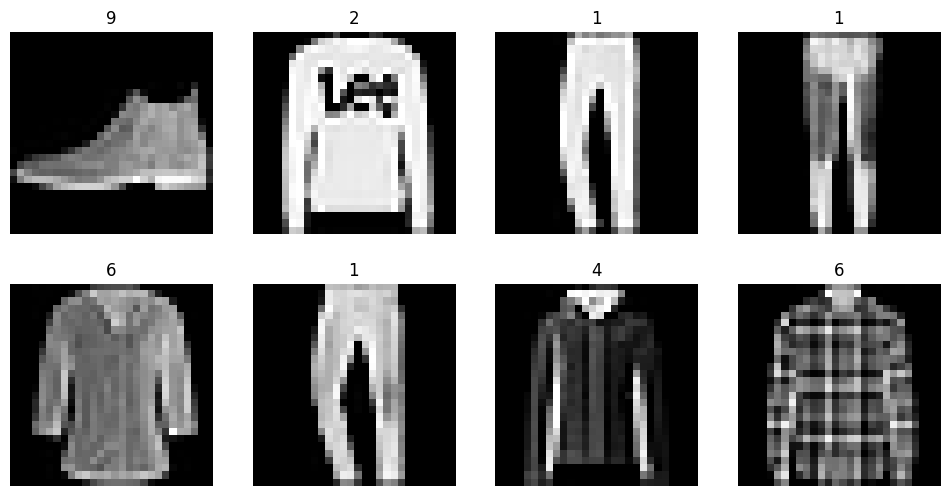

In [41]:
for data in test_loader:
    break

n, k = 4, batch_size_test // 4 + 1 * int((batch_size_test % 4) > 0)
images = data[0].cpu().numpy()
labels = data[1].cpu().numpy()
fig, ax = plt.subplots(k, n, figsize=(n*3, 3*k))
for ki in range(k):
    for ni in range(n):
        try:
            im = images[ni + ki*4, 0, :, :]
            label = labels[ni + ki*4]
            ax[ki, ni].imshow(im, cmap="gray")
            ax[ki, ni].set_title(str(label))
            ax[ki, ni].axis("off")
        except:
            pass

In [42]:
class FashionCNN(nn.Module):
    def __init__(self, kernel_size=3, padding=1):
        super(FashionCNN, self).__init__()

        self.k = kernel_size
        self.p = padding

        # 1 канал -> 16 -> 32 -> 64
        self.conv1 = nn.Conv2d(1, 16, kernel_size=kernel_size, padding=padding)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=kernel_size, padding=padding)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=padding)

        self.pool = nn.MaxPool2d(2, 2)

        with torch.no_grad():
            x = torch.zeros(1, 1, 28, 28)
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = self.pool(F.relu(self.conv3(x)))
            self.flat_dim = x.view(1, -1).shape[1]
            print(f"[init] kernel={kernel_size}, padding={padding}, "
                  f"feature map size after convs+pool: {x.shape}")

        self.fc1 = nn.Linear(self.flat_dim, 100)
        self.fc2 = nn.Linear(100, 10)

    def forward(self, x):
        # conv1
        x1 = self.conv1(x)
        x1_act = F.relu(x1)
        x1p = self.pool(x1_act)

        # conv2
        x2 = self.conv2(x1p)
        x2_act = F.relu(x2)
        x2p = self.pool(x2_act)

        # conv3
        x3 = self.conv3(x2p)
        x3_act = F.relu(x3)
        x3p = self.pool(x3_act)

        x_flat = x3p.view(x3p.size(0), -1)
        x_fc = F.relu(self.fc1(x_flat))
        logits = self.fc2(x_fc)
        probs = F.softmax(logits, dim=1)

        return probs, x1p, x2p, x3p

In [43]:
criterion = nn.CrossEntropyLoss()

def train_fashion(net, optimizer, num_epochs, name="model"):
    net.train()
    for epoch in range(num_epochs):
        running_loss, running_items, running_right = 0.0, 0.0, 0.0
        for i, batch in enumerate(train_loader):
            inputs, labels = batch[0].to(device), batch[1].to(device)

            optimizer.zero_grad()

            outputs, _, _, _ = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_items += len(labels)
            running_right += (labels == torch.max(outputs, 1)[1]).sum()

            if i % 300 == 0:
                net.eval()
                print(f'{name}. Epoch [{epoch+1}/{num_epochs}]. '
                      f'Step [{i+1}/{len(train_loader)}]. '
                      f'Loss: {running_loss / running_items:.3f}. '
                      f'Acc: {running_right / running_items:.3f}', end='. ')

                running_loss, running_items, running_right = 0.0, 0.0, 0.0

                # оценка на тесте
                test_running_right, test_running_total = 0.0, 0.0
                for tbatch in test_loader:
                    tinputs, tlabels = tbatch[0].to(device), tbatch[1].to(device)
                    toutputs, _, _, _ = net(tinputs)
                    test_running_total += len(tlabels)
                    test_running_right += (tlabels
                                           == torch.max(toutputs, 1)[1]).sum()

                print(f'Test acc: {test_running_right / test_running_total:.3f}')
                net.train()

    print(f'Training {name} finished!')

    net.eval()
    test_running_right, test_running_total = 0.0, 0.0
    with torch.no_grad():
        for tbatch in test_loader:
            tinputs, tlabels = tbatch[0].to(device), tbatch[1].to(device)
            toutputs, _, _, _ = net(tinputs)
            test_running_total += len(tlabels)
            test_running_right += (tlabels
                                   == torch.max(toutputs, 1)[1]).sum()
    final_acc = (test_running_right / test_running_total).item()
    print(f'Final test acc for {name}: {final_acc:.3f}')
    return final_acc

In [44]:
net_3 = FashionCNN(kernel_size=3, padding=1).to(device)
optimizer_3 = torch.optim.Adam(net_3.parameters(), lr=0.001)

acc3 = train_fashion(net_3, optimizer_3, num_epochs=5,
                     name="FashionCNN_3x3_pad1")

net_5 = FashionCNN(kernel_size=5, padding=2).to(device)
optimizer_5 = torch.optim.Adam(net_5.parameters(), lr=0.001)

acc5 = train_fashion(net_5, optimizer_5, num_epochs=5,
                     name="FashionCNN_5x5_pad2")

print(f"\nAcc 3x3, pad=1: {acc3:.3f}")
print(f"Acc 5x5, pad=2: {acc5:.3f}")

[init] kernel=3, padding=1, feature map size after convs+pool: torch.Size([1, 64, 3, 3])
FashionCNN_3x3_pad1. Epoch [1/5]. Step [1/938]. Loss: 0.036. Acc: 0.156. Test acc: 0.100
FashionCNN_3x3_pad1. Epoch [1/5]. Step [301/938]. Loss: 0.028. Acc: 0.655. Test acc: 0.748
FashionCNN_3x3_pad1. Epoch [1/5]. Step [601/938]. Loss: 0.027. Acc: 0.767. Test acc: 0.784
FashionCNN_3x3_pad1. Epoch [1/5]. Step [901/938]. Loss: 0.026. Acc: 0.800. Test acc: 0.810
FashionCNN_3x3_pad1. Epoch [2/5]. Step [1/938]. Loss: 0.025. Acc: 0.875. Test acc: 0.810
FashionCNN_3x3_pad1. Epoch [2/5]. Step [301/938]. Loss: 0.026. Acc: 0.820. Test acc: 0.825
FashionCNN_3x3_pad1. Epoch [2/5]. Step [601/938]. Loss: 0.025. Acc: 0.832. Test acc: 0.833
FashionCNN_3x3_pad1. Epoch [2/5]. Step [901/938]. Loss: 0.025. Acc: 0.840. Test acc: 0.847
FashionCNN_3x3_pad1. Epoch [3/5]. Step [1/938]. Loss: 0.025. Acc: 0.891. Test acc: 0.845
FashionCNN_3x3_pad1. Epoch [3/5]. Step [301/938]. Loss: 0.025. Acc: 0.855. Test acc: 0.842
Fashion

True label: 9
Pred 3x3: 9
Pred 5x5: 9


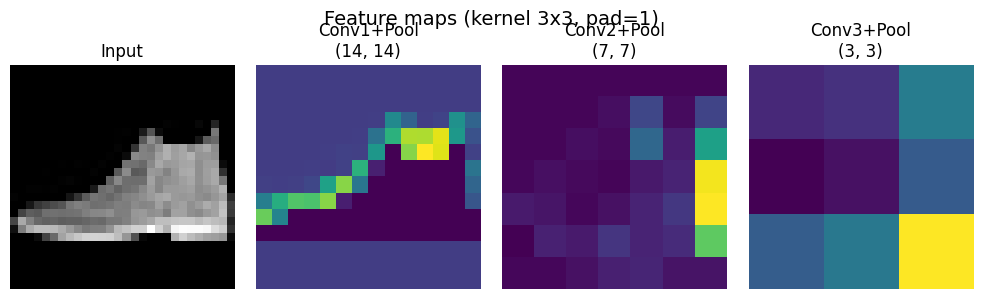

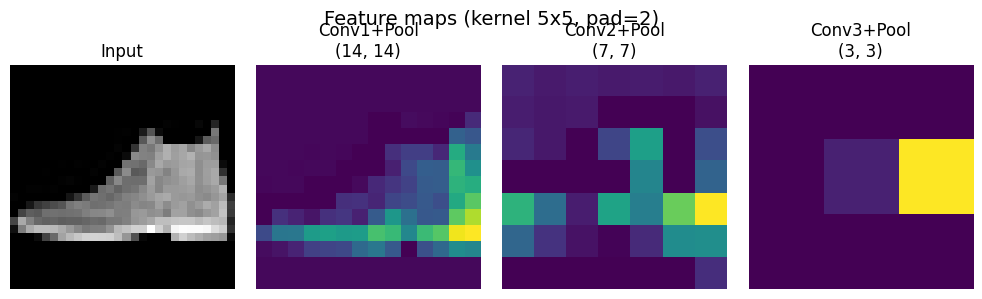

[init] kernel=3, padding=1, feature map size after convs+pool: torch.Size([1, 64, 3, 3])

kernel=3, padding=1
 after Conv1+Pool: (1, 16, 14, 14)
 after Conv2+Pool: (1, 32, 7, 7)
 after Conv3+Pool: (1, 64, 3, 3)
[init] kernel=5, padding=2, feature map size after convs+pool: torch.Size([1, 64, 3, 3])

kernel=5, padding=2
 after Conv1+Pool: (1, 16, 14, 14)
 after Conv2+Pool: (1, 32, 7, 7)
 after Conv3+Pool: (1, 64, 3, 3)


In [45]:
sample_imgs, sample_labels = next(iter(test_loader))
m0 = 0

img = sample_imgs[m0:m0+1].to(device)  # [1,1,28,28]

net_3.eval()
net_5.eval()
with torch.no_grad():
    out3, x1_3, x2_3, x3_3 = net_3(img)
    out5, x1_5, x2_5, x3_5 = net_5(img)

print("True label:", sample_labels[m0].item())
print("Pred 3x3:", torch.argmax(out3, 1).item())
print("Pred 5x5:", torch.argmax(out5, 1).item())

def show_feature_maps(x1, x2, x3, title_prefix="3x3"):
    f1 = x1[0, 0].cpu().numpy()
    f2 = x2[0, 0].cpu().numpy()
    f3 = x3[0, 0].cpu().numpy()

    plt.figure(figsize=(10, 3))
    plt.suptitle(f"Feature maps ({title_prefix})", fontsize=14)

    plt.subplot(1, 4, 1)
    plt.imshow(sample_imgs[m0, 0].numpy(), cmap="gray")
    plt.title("Input")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(f1, cmap="viridis")
    plt.title(f"Conv1+Pool\n{f1.shape}")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(f2, cmap="viridis")
    plt.title(f"Conv2+Pool\n{f2.shape}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(f3, cmap="viridis")
    plt.title(f"Conv3+Pool\n{f3.shape}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_feature_maps(x1_3, x2_3, x3_3, title_prefix="kernel 3x3, pad=1")
show_feature_maps(x1_5, x2_5, x3_5, title_prefix="kernel 5x5, pad=2")


def print_shapes(kernel_size, padding):
    net_tmp = FashionCNN(kernel_size=kernel_size, padding=padding).to(device)
    with torch.no_grad():
        x = torch.zeros(1, 1, 28, 28).to(device)
        _, x1, x2, x3 = net_tmp(x)
        print(f"\nkernel={kernel_size}, padding={padding}")
        print(" after Conv1+Pool:", tuple(x1.shape))
        print(" after Conv2+Pool:", tuple(x2.shape))
        print(" after Conv3+Pool:", tuple(x3.shape))

print_shapes(3, 1)
print_shapes(5, 2)